# -------------------------------------------------------------
# IMAGE HISTOGRAM ANALYSIS
# -------------------------------------------------------------
This code downloads an image from a URL and displays its
histogram (intensity distribution) for each RGB channel.


In [1]:
# Step 1: Import necessary libraries
import cv2                          # OpenCV for image processing
import numpy as np                 # NumPy for numerical operations
import matplotlib.pyplot as plt    # Matplotlib for plotting
import urllib.request              # To download image from the internet
import ssl                         # To avoid certificate verification errors

Step 2: Define the image URL

In [13]:
image_url = "https://drive.google.com/uc?export=download&id=1B0aNZy4zDQ1JqGlbN3YEllOTF9yApA7B"


Histogram is a graphical representation of the distribution of pixel intensities in an image.

For color images, we compute histograms separately for Red, Green, and Blue channels.

Step 3: Download the image from the URL and convert it to a format OpenCV can use

In [14]:
# STEP: Load image from URL
context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_np = np.asarray(bytearray(resp.read()), dtype="uint8")
image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

# ✅ Check if image is loaded
if image is None:
    print("❌ Error: Image could not be loaded. Check the URL.")
else:
    print("✅ Image loaded successfully.")

✅ Image loaded successfully.


Step 4: Convert BGR image to RGB for correct display in matplotlib

In [15]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Step 5: Display the original image

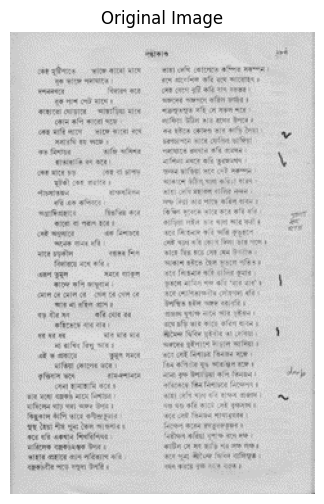

In [16]:
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

Step 6: Compute and plot histogram for each RGB channel

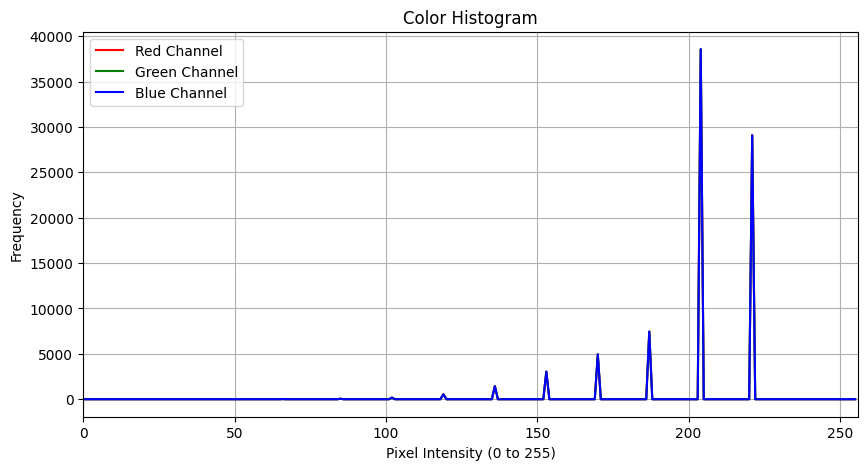

In [17]:
# Define color labels for channels
colors = ('r', 'g', 'b')
channel_names = ('Red', 'Green', 'Blue')

plt.figure(figsize=(10, 5))
for i, color in enumerate(colors):
    # cv2.calcHist calculates the histogram for each channel
    # Arguments: image (list), channel index, mask (None), histSize (256 bins), and range (0 to 256)
    hist = cv2.calcHist([image], [i], None, [256], [0, 256])

    # Plot histogram
    plt.plot(hist, color=color, label=f'{channel_names[i]} Channel')
    plt.xlim([0, 256])  # Intensity range
    plt.xlabel("Pixel Intensity (0 to 255)")
    plt.ylabel("Frequency")
    plt.title("Color Histogram")

plt.legend()
plt.grid(True)
plt.show()